# Risk Management

## Objective

This notebook evaluates the trading signals generated by the AI Trading Agent from a risk management perspective.

The analysis includes:

- Trade Profit and Loss
- Win Rate
- Average Profit
- Average Loss
- Profit Factor
- Maximum Drawdown
- Cumulative Returns

These metrics help assess the quality and sustainability of the generated trading strategy.

## Risk Management Workflow

```
Generated Trading Signals
          ↓
Trade Log
          ↓
Profit & Loss Analysis
          ↓
Risk Metrics
          ↓
Drawdown Analysis
          ↓
Performance Evaluation
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
trade = pd.read_csv("../data/trade_log.csv")

trade.head()

,TradeID,PairName,StrategyName,SignalType,Direction,EntryPrice,ExitPrice,EntryDateTime,ExitDateTime,PositionSize,PnL,PnL_Pips,HoldingDays,Commission,IsOpen
0,1,USD/JPY,MACD_Trend,BUY,LONG,154.16999,154.17229,2024-07-15,2024-07-17 23:45:36.000000000,100000,2300.0,23.0,2.99,7.0,False
1,2,USD/INR,MA_Cross,STRONG_SELL,SHORT,83.90144,83.90070,2024-02-08,2024-02-10 11:45:36.000000000,100000,740.0,7.4,2.49,7.0,False
2,3,USD/JPY,RL_PPO,BUY,LONG,150.56125,150.56093,2024-06-26,2024-06-28 10:19:12.000000000,100000,-320.0,-3.2,2.43,7.0,False
3,4,GBP/USD,ML_RF,SELL,SHORT,1.23636,1.23434,2024-03-26,2024-03-28 14:24:00.000000000,100000,202.0,20.2,2.60,7.0,False
4,5,AUD/USD,RL_PPO,BUY,LONG,0.66810,0.66700,2024-06-05,2024-06-06 11:02:24.000000000,100000,-110.0,-11.0,1.46,7.0,False


In [3]:
# Display dataset information

print("Trade Log Information")
trade.info()

print("\nFirst 5 Rows")
display(trade.head())

print("\nLast 5 Rows")
display(trade.tail())

print("\nColumn Names")
print(trade.columns.tolist())

Trade Log Information
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TradeID        150 non-null    int64  
 1   PairName       150 non-null    str    
 2   StrategyName   150 non-null    str    
 3   SignalType     150 non-null    str    
 4   Direction      150 non-null    str    
 5   EntryPrice     150 non-null    float64
 6   ExitPrice      150 non-null    float64
 7   EntryDateTime  150 non-null    str    
 8   ExitDateTime   150 non-null    str    
 9   PositionSize   150 non-null    int64  
 10  PnL            150 non-null    float64
 11  PnL_Pips       150 non-null    float64
 12  HoldingDays    150 non-null    float64
 13  Commission     150 non-null    float64
 14  IsOpen         150 non-null    bool   
dtypes: bool(1), float64(6), int64(2), str(6)
memory usage: 26.2 KB

First 5 Rows


,TradeID,PairName,StrategyName,SignalType,Direction,EntryPrice,ExitPrice,EntryDateTime,ExitDateTime,PositionSize,PnL,PnL_Pips,HoldingDays,Commission,IsOpen
0,1,USD/JPY,MACD_Trend,BUY,LONG,154.16999,154.17229,2024-07-15,2024-07-17 23:45:36.000000000,100000,2300.0,23.0,2.99,7.0,False
1,2,USD/INR,MA_Cross,STRONG_SELL,SHORT,83.90144,83.90070,2024-02-08,2024-02-10 11:45:36.000000000,100000,740.0,7.4,2.49,7.0,False
2,3,USD/JPY,RL_PPO,BUY,LONG,150.56125,150.56093,2024-06-26,2024-06-28 10:19:12.000000000,100000,-320.0,-3.2,2.43,7.0,False
3,4,GBP/USD,ML_RF,SELL,SHORT,1.23636,1.23434,2024-03-26,2024-03-28 14:24:00.000000000,100000,202.0,20.2,2.60,7.0,False
4,5,AUD/USD,RL_PPO,BUY,LONG,0.66810,0.66700,2024-06-05,2024-06-06 11:02:24.000000000,100000,-110.0,-11.0,1.46,7.0,False



Last 5 Rows


,TradeID,PairName,StrategyName,SignalType,Direction,EntryPrice,ExitPrice,EntryDateTime,ExitDateTime,PositionSize,PnL,PnL_Pips,HoldingDays,Commission,IsOpen
145,146,EUR/USD,Composite,BUY,LONG,1.05878,1.05588,2024-03-04,2024-03-07 06:00:00.000000000,100000,-290.0,-29.0,3.25,7.0,False
146,147,EUR/USD,ML_RF,BUY,LONG,1.11032,1.11333,2024-05-29,2024-06-02 01:40:48.000000000,100000,301.0,30.1,4.07,7.0,False
147,148,GBP/USD,MA_Cross,STRONG_SELL,SHORT,1.24366,1.24291,2024-03-04,2024-03-05 16:48:00.000000000,100000,75.0,7.5,1.70,7.0,False
148,149,EUR/USD,RSI_Reversal,STRONG_SELL,SHORT,1.06391,1.06616,2024-05-18,2024-05-20 23:31:12.000000000,100000,-225.0,-22.5,2.98,7.0,False
149,150,USD/JPY,ML_XGB,STRONG_SELL,SHORT,152.47311,152.47611,2024-02-14,2024-02-17 15:21:36.000000000,100000,-3000.0,-30.0,3.64,7.0,False



Column Names
['TradeID', 'PairName', 'StrategyName', 'SignalType', 'Direction', 'EntryPrice', 'ExitPrice', 'EntryDateTime', 'ExitDateTime', 'PositionSize', 'PnL', 'PnL_Pips', 'HoldingDays', 'Commission', 'IsOpen']


In [4]:
# Winning Trades

winning_trades = trade[trade["PnL"] > 0]

# Losing Trades

losing_trades = trade[trade["PnL"] <= 0]

# Calculate Win Rate

win_rate = (len(winning_trades) / len(trade)) * 100

print("Total Trades :", len(trade))
print("Winning Trades :", len(winning_trades))
print("Losing Trades :", len(losing_trades))
print(f"Win Rate : {win_rate:.2f}%")

Total Trades : 150
Winning Trades : 84
Losing Trades : 66
Win Rate : 56.00%


In [5]:
# Total Profit

total_profit = trade["PnL"].sum()

print(f"Total Profit/Loss : {total_profit:.2f}")

Total Profit/Loss : 1915.00


In [6]:
average_profit = trade["PnL"].mean()

print(f"Average Profit per Trade : {average_profit:.2f}")


Average Profit per Trade : 12.77


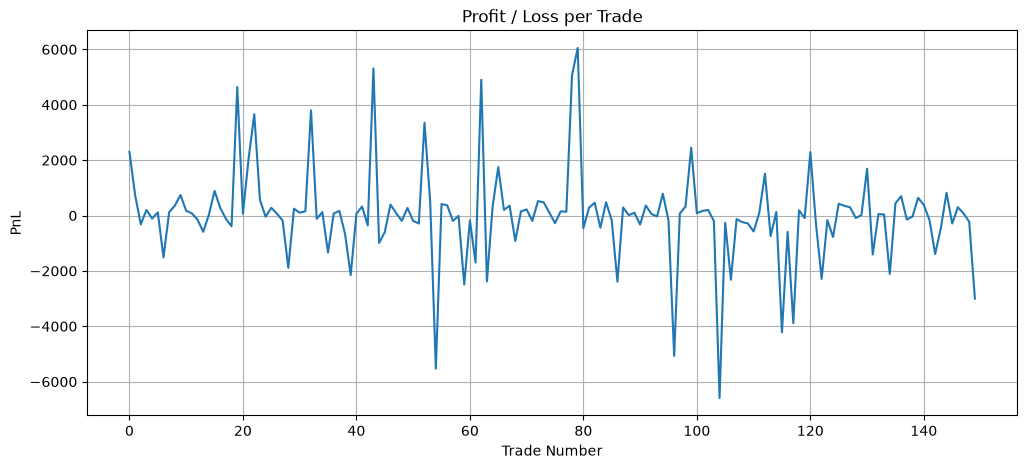

In [7]:
plt.figure(figsize=(12,5))

plt.plot(trade["PnL"])

plt.title("Profit / Loss per Trade")

plt.xlabel("Trade Number")

plt.ylabel("PnL")

plt.grid(True)

plt.show()

In [8]:
# Calculate cumulative profit

trade["Cumulative_PnL"] = trade["PnL"].cumsum()

trade[["TradeID", "PnL", "Cumulative_PnL"]].head()

,TradeID,PnL,Cumulative_PnL
0,1,2300.0,2300.0
1,2,740.0,3040.0
2,3,-320.0,2720.0
3,4,202.0,2922.0
4,5,-110.0,2812.0


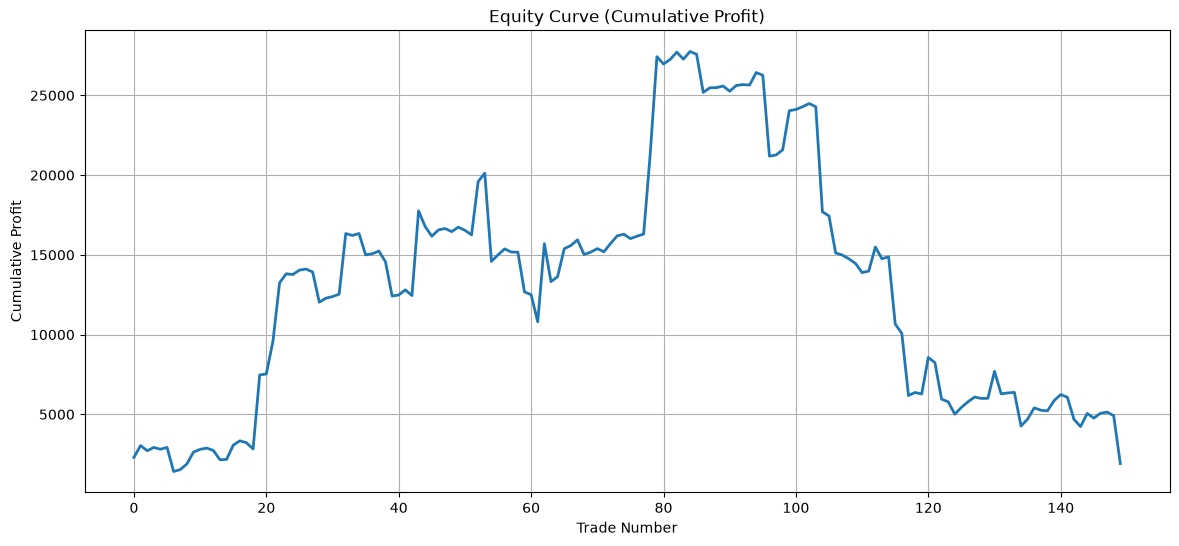

In [9]:
plt.figure(figsize=(14,6))

plt.plot(trade["Cumulative_PnL"], linewidth=2)

plt.title("Equity Curve (Cumulative Profit)")

plt.xlabel("Trade Number")

plt.ylabel("Cumulative Profit")

plt.grid(True)

plt.show()

In [10]:
# Running Maximum of Equity

trade["Running_Max"] = trade["Cumulative_PnL"].cummax()

trade[[
    "Cumulative_PnL",
    "Running_Max"
]].head(15)

,Cumulative_PnL,Running_Max
0,2300.0,2300.0
1,3040.0,3040.0
2,2720.0,3040.0
3,2922.0,3040.0
4,2812.0,3040.0
5,2926.0,3040.0
6,1416.0,3040.0
7,1535.0,3040.0
8,1893.0,3040.0
9,2633.0,3040.0


In [11]:
# Drawdown

trade["Drawdown"] = (
    trade["Running_Max"]
    - trade["Cumulative_PnL"]
)

trade[[
    "Cumulative_PnL",
    "Running_Max",
    "Drawdown"
]].head(15)

,Cumulative_PnL,Running_Max,Drawdown
0,2300.0,2300.0,0.0
1,3040.0,3040.0,0.0
2,2720.0,3040.0,320.0
3,2922.0,3040.0,118.0
4,2812.0,3040.0,228.0
5,2926.0,3040.0,114.0
6,1416.0,3040.0,1624.0
7,1535.0,3040.0,1505.0
8,1893.0,3040.0,1147.0
9,2633.0,3040.0,407.0


In [12]:
# Maximum Drawdown

max_drawdown = trade["Drawdown"].max()

print(f"Maximum Drawdown : {max_drawdown:.2f}")

Maximum Drawdown : 25837.00


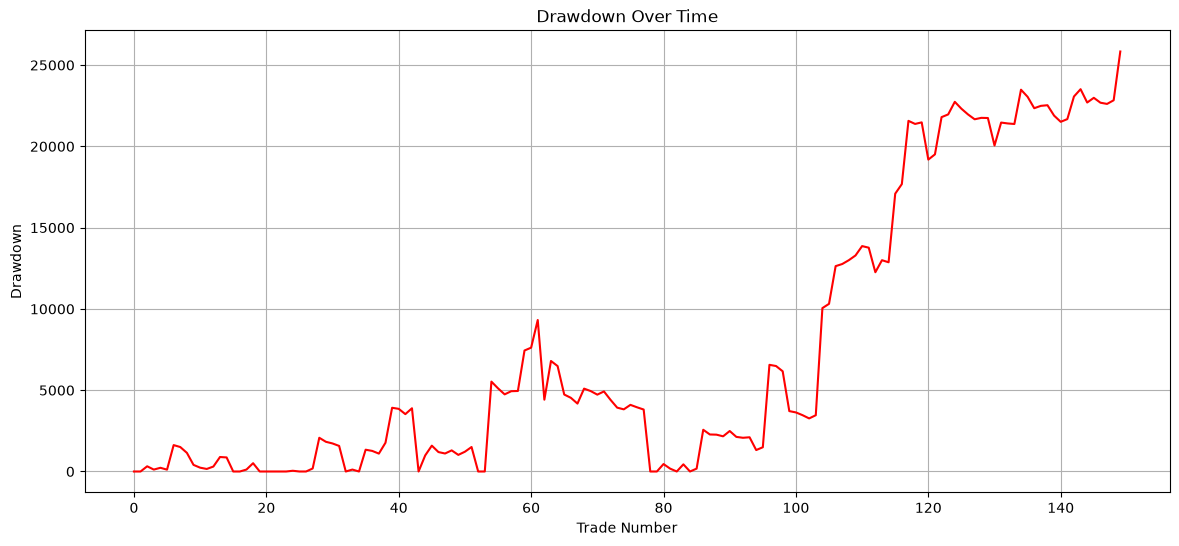

In [13]:
plt.figure(figsize=(14,6))

plt.plot(
    trade["Drawdown"],
    color="red"
)

plt.title("Drawdown Over Time")

plt.xlabel("Trade Number")

plt.ylabel("Drawdown")

plt.grid(True)

plt.show()

In [14]:
# Calculate Gross Profit

gross_profit = trade.loc[trade["PnL"] > 0, "PnL"].sum()

# Calculate Gross Loss

gross_loss = abs(
    trade.loc[trade["PnL"] < 0, "PnL"].sum()
)

print("Gross Profit :", gross_profit)
print("Gross Loss :", gross_loss)

Gross Profit : 70071.0
Gross Loss : 68156.0


In [15]:
# Profit Factor

profit_factor = gross_profit / gross_loss

print(f"Profit Factor : {profit_factor:.2f}")

Profit Factor : 1.03


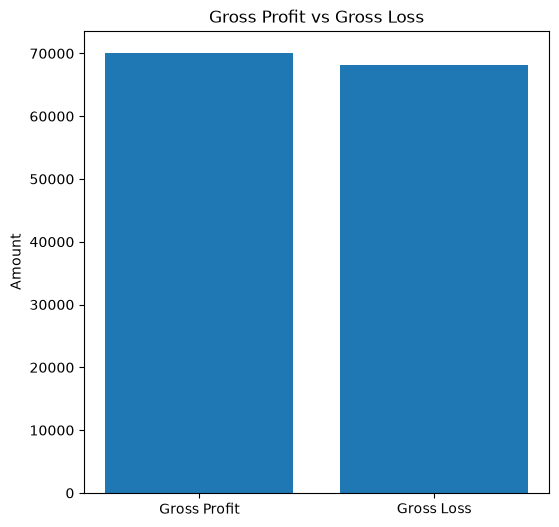

In [16]:
plt.figure(figsize=(6,6))

plt.bar(
    ["Gross Profit", "Gross Loss"],
    [gross_profit, gross_loss]
)

plt.title("Gross Profit vs Gross Loss")

plt.ylabel("Amount")

plt.show()

In [17]:
# Calculate Mean Return

mean_return = trade["PnL"].mean()

# Calculate Standard Deviation

std_return = trade["PnL"].std()

print("Average Return :", mean_return)

print("Risk (Std Dev) :", std_return)

Average Return : 12.766666666666667
Risk (Std Dev) : 1664.8479641840797


In [18]:
# Sharpe Ratio

sharpe_ratio = mean_return / std_return

print(f"Sharpe Ratio : {sharpe_ratio:.3f}")

Sharpe Ratio : 0.008


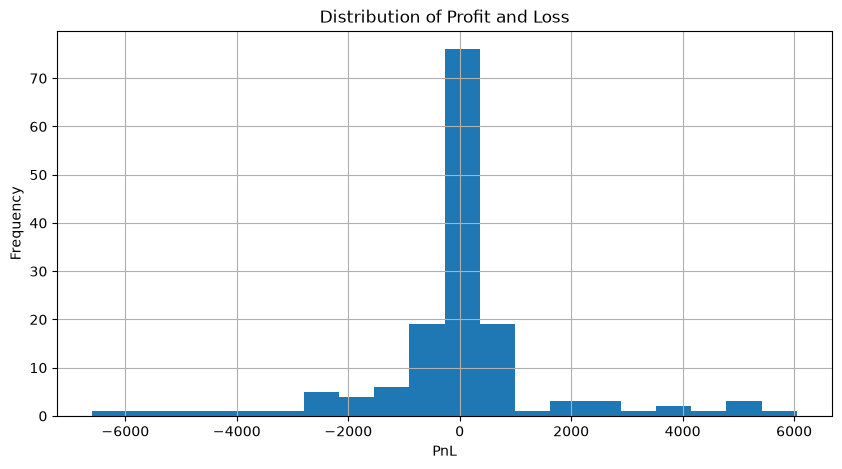

In [19]:
plt.figure(figsize=(10,5))

plt.hist(trade["PnL"], bins=20)

plt.title("Distribution of Profit and Loss")

plt.xlabel("PnL")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

## Conclusion

Risk management analysis indicates the effectiveness of the AI-generated trading signals.

The calculated metrics, including Win Rate, Average Profit, Profit Factor, and Maximum Drawdown, provide insights into the overall stability and profitability of the trading strategy.

These outputs are later used within the Power BI dashboard for interactive visualization.